In [1]:
# Notebooks run from the notebooks folder, so the src folder is added to the path.
import sys
from pathlib import Path

src_folder = Path.cwd().parent / "src"
sys.path.insert(0, str(src_folder))

In [2]:
# Reloads edited modules in src without restarting the kernel.
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

import config

In [4]:
import joblib
from prepare import load_chips
from features import build_features_for_chip

model = joblib.load(config.MODEL_FILE)
chips = load_chips()

# Empty array matching the study area dimensions.
prediction_map = np.zeros(
    (config.STUDY_AREA.height, config.STUDY_AREA.width),
    dtype="uint8",
)

for chip in tqdm(chips):
    # Features must match training exactly, as a mismatch produces no error.
    features = build_features_for_chip(chip["img"])

    flat_prediction = model.predict(features)

    # Reshaped to a 256 x 256 tile.
    square_prediction = flat_prediction.reshape(config.CHIP_SIZE, config.CHIP_SIZE)

    # Placed using the row and column recorded during tiling.
    row = chip["row"]
    col = chip["col"]
    prediction_map[row:row + config.CHIP_SIZE, col:col + config.CHIP_SIZE] = square_prediction

# The aligned label profile is reused so the output is correctly georeferenced.
aligned = rasterio.open(config.ALIGNED_LABELS_FILE)
settings = aligned.profile
aligned.close()

output = rasterio.open(config.PREDICTION_FILE, "w", **settings)
output.write(prediction_map, 1)
output.close()

print("Predicted canopy fraction:", round(prediction_map.mean(), 3))

  0%|          | 0/1911 [00:00<?, ?it/s]

Predicted canopy fraction: 0.31


In [5]:
import geopandas as gpd
from rasterstats import zonal_stats
from shapely.geometry import box

# Extent and coordinate system of the prediction.
prediction = rasterio.open(config.PREDICTION_FILE)
study_area_outline = box(*prediction.bounds)
prediction_crs = prediction.crs
prediction.close()

# zonal_stats does not reproject; a CRS mismatch returns None without an error.
neighborhoods = gpd.read_file(config.NTA_FILE)
neighborhoods = neighborhoods.to_crs(prediction_crs)

# The name column is ntaname or NTAName depending on the file version.
if "ntaname" in neighborhoods.columns:
    NAME_COLUMN = "ntaname"
else:
    NAME_COLUMN = "NTAName"
print("Neighborhood names are in column:", NAME_COLUMN)

# Only neighborhoods intersecting the study area are retained.
neighborhoods = neighborhoods[neighborhoods.intersects(study_area_outline)].copy()
print("Neighborhoods overlapping the study area:", len(neighborhoods))

# The mean of a binary raster within a polygon gives the canopy percentage.
predicted_stats = zonal_stats(
    neighborhoods, str(config.PREDICTION_FILE), stats=["mean"], nodata=255
)
reference_stats = zonal_stats(
    neighborhoods, str(config.ALIGNED_LABELS_FILE), stats=["mean"], nodata=255
)

predicted_percents = []
reference_percents = []

for result in predicted_stats:
    if result["mean"] is None:
        predicted_percents.append(np.nan)
    else:
        predicted_percents.append(result["mean"] * 100)

for result in reference_stats:
    if result["mean"] is None:
        reference_percents.append(np.nan)
    else:
        reference_percents.append(result["mean"] * 100)

neighborhoods["canopy_predicted"] = predicted_percents
neighborhoods["canopy_reference"] = reference_percents
neighborhoods["error"] = neighborhoods["canopy_predicted"] - neighborhoods["canopy_reference"]

# Partially covered neighborhoods are underestimated, so they are flagged.
neighborhoods["fully_inside"] = neighborhoods.within(study_area_outline)

neighborhoods.to_file(config.NEIGHBORHOOD_RESULTS_FILE, driver="GeoJSON")

fully_inside = neighborhoods[neighborhoods["fully_inside"]]
print("Fully inside the study area:", len(fully_inside))

Neighborhood names are in column: ntaname
Neighborhoods overlapping the study area: 32
Fully inside the study area: 9


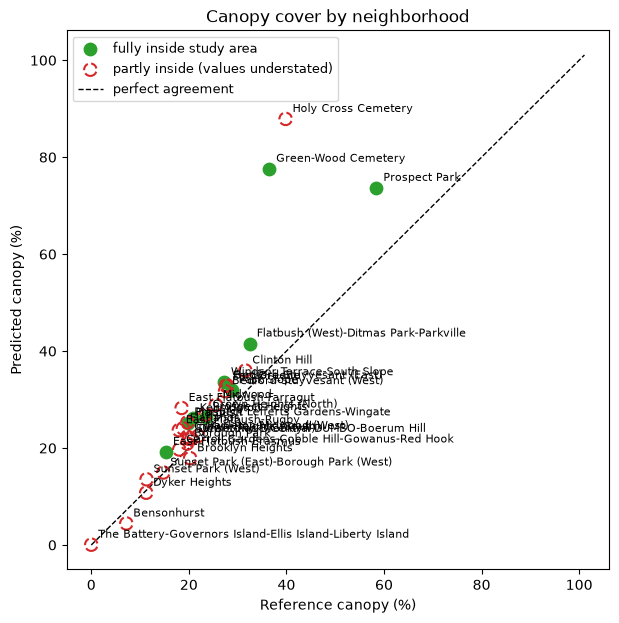

Based on 9 fully-inside neighborhoods
  Average error:      10.3 percentage points
  Average size of error: 10.3 percentage points
23 more partly overlap and are excluded


In [6]:
fully_inside = neighborhoods[neighborhoods["fully_inside"]]
partly_inside = neighborhoods[~neighborhoods["fully_inside"]]

figure, axes = plt.subplots(figsize=(7, 7))

# Neighborhoods fully within the study area.
axes.scatter(
    fully_inside["canopy_reference"],
    fully_inside["canopy_predicted"],
    s=80,
    color="tab:green",
    label="fully inside study area",
    zorder=3,
)

# Partially covered neighborhoods, whose values are understated.
axes.scatter(
    partly_inside["canopy_reference"],
    partly_inside["canopy_predicted"],
    s=80,
    facecolors="none",
    edgecolors="tab:red",
    linestyle="--",
    linewidth=1.5,
    label="partly inside (values understated)",
    zorder=3,
)

# Neighborhood labels.
for index, row in neighborhoods.iterrows():
    axes.annotate(
        row[NAME_COLUMN],
        xy=(row["canopy_reference"], row["canopy_predicted"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

# Line of perfect agreement.
highest = max(
    neighborhoods["canopy_reference"].max(),
    neighborhoods["canopy_predicted"].max(),
)
axes.plot([0, highest * 1.15], [0, highest * 1.15],
          "k--", linewidth=1, label="perfect agreement", zorder=1)

axes.set_xlabel("Reference canopy (%)")
axes.set_ylabel("Predicted canopy (%)")
axes.set_title("Canopy cover by neighborhood")
axes.legend(loc="upper left", fontsize=9)

plt.savefig(config.FIGURES_FOLDER / "04_neighborhood_scatter.png", dpi=120, bbox_inches="tight")
plt.show()

# Statistics use fully covered neighborhoods only.
average_error = fully_inside["error"].mean()
average_size_of_error = fully_inside["error"].abs().mean()

print("Based on", len(fully_inside), "fully-inside neighborhoods")
print("  Average error:     ", round(average_error, 1), "percentage points")
print("  Average size of error:", round(average_size_of_error, 1), "percentage points")
print(len(partly_inside), "more partly overlap and are excluded")

N = 9 neighborhoods (NTAs) were fully within the NAIP imagery tile.

In [7]:
worst_first = fully_inside.sort_values("error", key=abs, ascending=False)

print(worst_first[[NAME_COLUMN, "canopy_reference", "canopy_predicted", "error"]].to_string(index=False))

                              ntaname  canopy_reference  canopy_predicted     error
                  Green-Wood Cemetery         36.476667         77.617959 41.141292
                        Prospect Park         58.446184         73.679423 15.233239
Flatbush (West)-Ditmas Park-Parkville         32.496933         41.554141  9.057208
          Windsor Terrace-South Slope         27.198414         33.588344  6.389930
                           Kensington         20.792211         26.153792  5.361581
                             Flatbush         19.927157         25.170141  5.242985
                East Flatbush-Erasmus         15.320351         19.228521  3.908170
                           Park Slope         28.794962         31.937676  3.142713
                     Prospect Heights         23.456732         26.412886  2.956154


In [8]:
import folium

map_data = gpd.read_file(config.NEIGHBORHOOD_RESULTS_FILE)

# Web maps require latitude and longitude; the analysis used a projected system.
map_data = map_data.to_crs(4326)

In [9]:
# Only required columns are kept, as folium cannot serialize the date fields.
map_data = map_data[[
    NAME_COLUMN,
    "canopy_predicted",
    "canopy_reference",
    "error",
    "fully_inside",
    "geometry",
]].copy()

# Coverage description for the tooltip.
coverage_labels = []
for is_full in map_data["fully_inside"]:
    if is_full:
        coverage_labels.append("Fully inside study area")
    else:
        coverage_labels.append("PARTLY inside - value understated")
map_data["coverage"] = coverage_labels

# Map center.
center_point = map_data.geometry.union_all().centroid

canopy_map = folium.Map(
    location=[center_point.y, center_point.x],   # Order is [latitude, longitude]
    zoom_start=13,
    tiles="OpenStreetMap",
)

folium.Choropleth(
    geo_data=map_data,
    data=map_data,
    columns=[NAME_COLUMN, "canopy_predicted"],
    key_on="feature.properties." + NAME_COLUMN,
    fill_color="YlGn",
    fill_opacity=0.7,
    line_weight=0,           # Outlines are drawn by the GeoJson layer
    legend_name="Predicted tree canopy (%)",
).add_to(canopy_map)


def outline_style(feature):
    """Return a solid outline for full coverage and a dashed red outline for partial coverage."""
    is_full = feature["properties"]["fully_inside"]

    if is_full:
        return {
            "fillOpacity": 0,
            "color": "#444444",
            "weight": 1.5,
        }
    else:
        return {
            "fillOpacity": 0,
            "color": "#cc0000",
            "weight": 2.5,
            "dashArray": "8, 6",     # 8 px dash, 6 px gap
        }


# Outlines and tooltips, which Choropleth does not provide.
folium.GeoJson(
    map_data,
    style_function=outline_style,
    tooltip=folium.GeoJsonTooltip(
        fields=[NAME_COLUMN, "canopy_predicted", "canopy_reference",
                "error", "coverage"],
        aliases=["Neighborhood", "Predicted %", "Reference %",
                 "Error (pp)", "Coverage"],
        localize=True,
    ),
).add_to(canopy_map)

canopy_map.save(config.DOCS_FOLDER / "index.html")
canopy_map

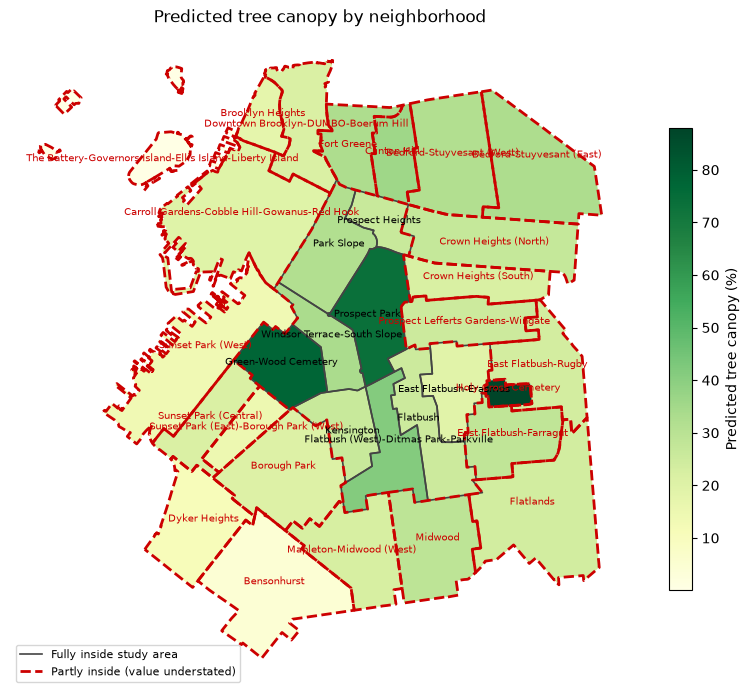

In [10]:
from matplotlib.lines import Line2D

figure, axes = plt.subplots(figsize=(10, 10))

# Fill by predicted canopy.
map_data.plot(
    column="canopy_predicted",
    cmap="YlGn",
    legend=True,
    linewidth=0,
    ax=axes,
    legend_kwds={"label": "Predicted tree canopy (%)", "shrink": 0.6},
)

# Solid outline for fully covered neighborhoods.
fully_inside_shapes = map_data[map_data["fully_inside"]]
fully_inside_shapes.boundary.plot(
    ax=axes,
    edgecolor="#444444",
    linewidth=1.2,
)

# Dashed red outline for partially covered neighborhoods.
partly_inside_shapes = map_data[~map_data["fully_inside"]]
if len(partly_inside_shapes) > 0:
    partly_inside_shapes.boundary.plot(
        ax=axes,
        edgecolor="#cc0000",
        linewidth=2,
        linestyle="--",
    )

# Neighborhood labels.
for index, row in map_data.iterrows():
    label_point = row["geometry"].representative_point()

    if row["fully_inside"]:
        label_color = "black"
    else:
        label_color = "#cc0000"

    axes.annotate(
        row[NAME_COLUMN],
        xy=(label_point.x, label_point.y),
        ha="center",
        fontsize=7,
        color=label_color,
    )

# Legend entries for the outline styles.
legend_items = [
    Line2D([0], [0], color="#444444", linewidth=1.2,
           label="Fully inside study area"),
    Line2D([0], [0], color="#cc0000", linewidth=2, linestyle="--",
           label="Partly inside (value understated)"),
]
axes.legend(handles=legend_items, loc="lower left", fontsize=8)

axes.set_axis_off()
axes.set_title("Predicted tree canopy by neighborhood")

plt.savefig(config.FIGURES_FOLDER / "05_choropleth.png", dpi=120, bbox_inches="tight")
plt.show()

Link to interactive map: [Live map](https://geobrec.github.io/canopy-remote-sensing/)